## CREDIT CARD CUSTOMER SEGMENTATION ML

## IMPORT LIBRARIES

In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score

import joblib
import logging
import warnings
warnings.filterwarnings('ignore')

In [73]:
# LOGGING SETUP

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logging.info(" Pipeline Started")

pd.set_option('display.max_columns', None)

# LOAD DATA

def load_data(path):
    data = pd.read_csv(path)
    logging.info(f"Dataset loaded. Shape: {data.shape}")
    return data

df = load_data("Credit Card Customer Data.csv")

2026-04-19 17:01:38,975 - INFO -  Pipeline Started
2026-04-19 17:01:38,981 - INFO - Dataset loaded. Shape: (660, 7)


## DATA AUDIT

In [72]:
# DATA AUDIT

def data_audit(df):
    return pd.DataFrame({
        "Column": df.columns,
        "Missing": df.isnull().sum(),
        "Missing %": (df.isnull().sum()/len(df))*100,
        "Unique": df.nunique(),
        "Datatype": df.dtypes
    }).sort_values(by="Missing %", ascending=False)

print("\n DATA AUDIT:\n", data_audit(df))


 DATA AUDIT:
                                   Column  Missing  Missing %  Unique Datatype
Sl_No                              Sl_No        0        0.0     660    int64
Customer Key                Customer Key        0        0.0     655    int64
Avg_Credit_Limit        Avg_Credit_Limit        0        0.0     110    int64
Total_Credit_Cards    Total_Credit_Cards        0        0.0      10    int64
Total_visits_bank      Total_visits_bank        0        0.0       6    int64
Total_visits_online  Total_visits_online        0        0.0      16    int64
Total_calls_made        Total_calls_made        0        0.0      11    int64
TOTAL_VISITS                TOTAL_VISITS        0        0.0      18    int64
Cluster                          Cluster        0        0.0       3    int32


## DATA CLEANING

In [47]:

def clean_data(df):
    df = df.drop_duplicates()
    df = df.drop(columns=['CUST_ID'], errors='ignore')

    for col in df.columns:
        if df[col].dtype != 'object':
            ratio = df[col].isnull().mean()
            if ratio < 0.05:
                df[col].fillna(df[col].median(), inplace=True)
            elif ratio < 0.2:
                df[col].fillna(df[col].mean(), inplace=True)
            else:
                df[col].fillna(method='ffill', inplace=True)

    for col in ['CREDIT_LIMIT', 'MINIMUM_PAYMENTS']:
        if col in df.columns:
            df[col] = df[col].replace(0, df[col].median())

    return df

df = clean_data(df)


## OUTLIERS

In [25]:
# OUTLIERS

def handle_outliers(df):
    for col in df.select_dtypes(include=np.number).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = np.where(df[col] > upper, upper,
                  np.where(df[col] < lower, lower, df[col]))
    return df

df = handle_outliers(df)



## CORRECT FEATURE ENGINEERING

In [31]:

# CORRECT FEATURE ENGINEERING (YOUR DATASET)

def feature_engineering_correct(df):

    # Drop useless columns
    df = df.drop(columns=['Sl_No', 'Customer Key'], errors='ignore')

    # Total interaction
    df['TOTAL_VISITS'] = (
        df['Total_visits_bank'] +
        df['Total_visits_online'] +
        df['Total_calls_made']
    )

    # Online preference
    df['ONLINE_RATIO'] = df['Total_visits_online'] / (df['TOTAL_VISITS'] + 1)

    # Bank visit ratio
    df['BANK_RATIO'] = df['Total_visits_bank'] / (df['TOTAL_VISITS'] + 1)

    # Calls ratio
    df['CALL_RATIO'] = df['Total_calls_made'] / (df['TOTAL_VISITS'] + 1)

    # Credit per card
    df['CREDIT_PER_CARD'] = df['Avg_Credit_Limit'] / (df['Total_Credit_Cards'] + 1)

    # Interaction intensity
    df['ENGAGEMENT_SCORE'] = df['TOTAL_VISITS'] * df['Total_Credit_Cards']

    df.replace([np.inf, -np.inf], 0, inplace=True)

    print(" Correct Feature Engineering Done")

    return df

df = feature_engineering_correct(df)

 Correct Feature Engineering Done


## # SCALING (CLUSTERING)

In [48]:
# SCALING (CLUSTERING)

scaler_cluster = StandardScaler()
scaled_data = scaler_cluster.fit_transform(df)

## CLUSTERING

In [74]:
# CLUSTERING

kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

score = silhouette_score(scaled_data, df['Cluster'])
print("\nSilhouette Score:", score)



Silhouette Score: 0.295361269539851


 ## PCA VISUALIZATION

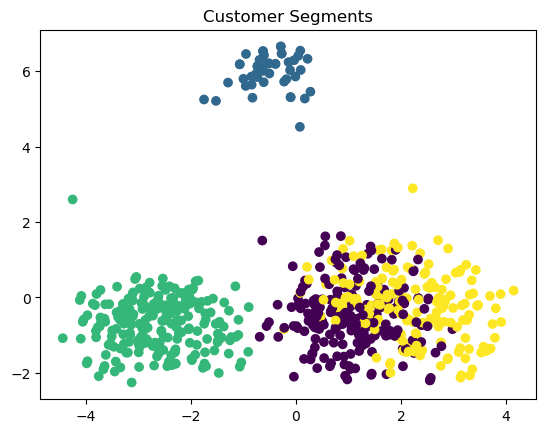

In [36]:
# PCA VISUALIZATION

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.scatter(pca_data[:,0], pca_data[:,1], c=df['Cluster'])
plt.title("Customer Segments")
plt.show()


## PREPARE DATA FOR ML

In [37]:
# PREPARE DATA FOR ML

X = df.drop('Cluster', axis=1)
y = df['Cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_ml = StandardScaler()
X_train = scaler_ml.fit_transform(X_train)
X_test = scaler_ml.transform(X_test)

In [50]:
# TRAIN MULTIPLE MODELS

models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


RandomForest
Accuracy: 0.9621212121212122
Confusion Matrix:
 [[33  0  1  2]
 [ 0 12  0  0]
 [ 0  0 49  0]
 [ 2  0  0 33]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93        36
           1       1.00      1.00      1.00        12
           2       0.98      1.00      0.99        49
           3       0.94      0.94      0.94        35

    accuracy                           0.96       132
   macro avg       0.97      0.96      0.97       132
weighted avg       0.96      0.96      0.96       132


GradientBoosting
Accuracy: 0.9621212121212122
Confusion Matrix:
 [[34  0  0  2]
 [ 0 12  0  0]
 [ 0  0 49  0]
 [ 3  0  0 32]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93        36
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        49
           3       0.94      0.91      0.93       

## CROSS VALIDATION

In [52]:
# CROSS VALIDATION

print("\n Cross Validation")
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name} CV Score:", scores.mean())


 Cross Validation
RandomForest CV Score: 0.9677807726864331
GradientBoosting CV Score: 0.9640071877807728


## HYPERPARAMETER TUNING

In [42]:
# HYPERPARAMETER TUNING

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\n Best Params:", grid.best_params_)



 Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


## FINAL MODEL EVALUATION

In [54]:
# FINAL MODEL EVALUATION

y_pred_best = best_model.predict(X_test)

print("\n FINAL MODEL")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Classification Report:\n", classification_report(y_test, y_pred_best))



 FINAL MODEL
Accuracy: 0.9621212121212122
Confusion Matrix:
 [[33  0  1  2]
 [ 0 12  0  0]
 [ 0  0 49  0]
 [ 2  0  0 33]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93        36
           1       1.00      1.00      1.00        12
           2       0.98      1.00      0.99        49
           3       0.94      0.94      0.94        35

    accuracy                           0.96       132
   macro avg       0.97      0.96      0.97       132
weighted avg       0.96      0.96      0.96       132



## FEATURE IMPORTANCE

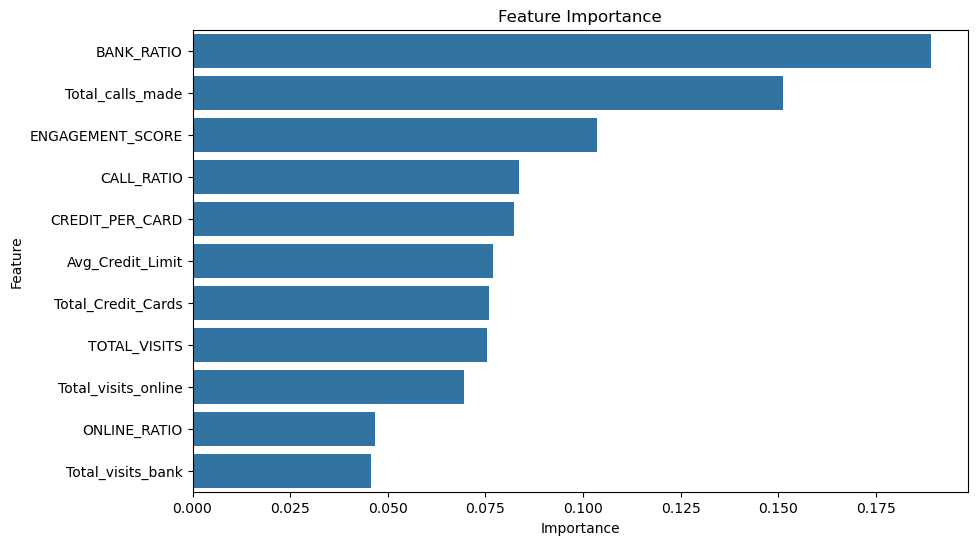

In [44]:
# FEATURE IMPORTANCE

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Feature Importance")
plt.show()

## PREDICTION FUNCTION

In [57]:
# PREDICTION FUNCTION

def predict_customer(input_data):
    input_df = pd.DataFrame([input_data], columns=X.columns)
    input_scaled = scaler_ml.transform(input_df)
    return best_model.predict(input_scaled)[0]

sample = X.iloc[0].to_dict()
print("\n Predicted Cluster:", predict_customer(sample))


 Predicted Cluster: 3


In [61]:

#  ONLY PREDICTION CODE


import pandas as pd


# SINGLE CUSTOMER PREDICTION

def predict_customer(input_data):
    
    # Convert input into DataFrame
    input_df = pd.DataFrame([input_data], columns=X.columns)
    
    # Scale input
    input_scaled = scaler_ml.transform(input_df)
    
    # Predict cluster
    prediction = model.predict(input_scaled)
    
    return prediction[0]



# EXAMPLE 1 (FROM DATASET)

sample = X.iloc[0].to_dict()
print("Predicted Cluster:", predict_customer(sample))



# EXAMPLE 2 (NEW CUSTOMER)

new_customer = {
    'Avg_Credit_Limit': 50000,
    'Total_Credit_Cards': 4,
    'Total_visits_bank': 2,
    'Total_visits_online': 5,
    'Total_calls_made': 1,
    'TOTAL_VISITS': 8,
    'ONLINE_RATIO': 5/8,
    'BANK_RATIO': 2/8,
    'CALL_RATIO': 1/8,
    'CREDIT_PER_CARD': 50000/4,
    'ENGAGEMENT_SCORE': 8*4
}

print("New Customer Prediction:", predict_customer(new_customer))

Predicted Cluster: 3
New Customer Prediction: 1


## GRAPH

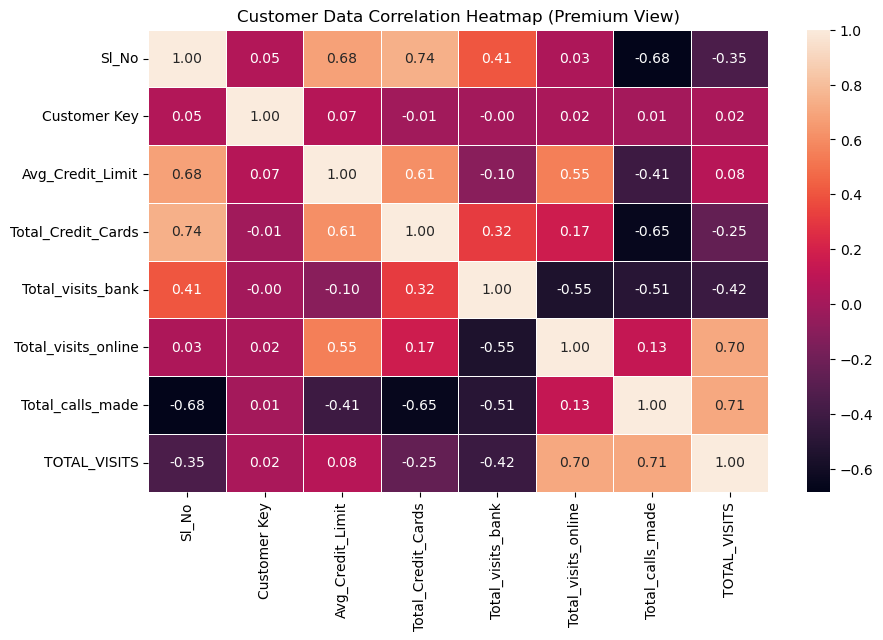

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("Credit Card Customer Data.csv")

# Feature Engineering (minimal but important)
df['TOTAL_VISITS'] = (
    df['Total_visits_bank'] +
    df['Total_visits_online'] +
    df['Total_calls_made']
)

# Select numeric columns
num_df = df.select_dtypes(include='number')

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", linewidths=0.5)

plt.title("Customer Data Correlation Heatmap (Premium View)")
plt.show()

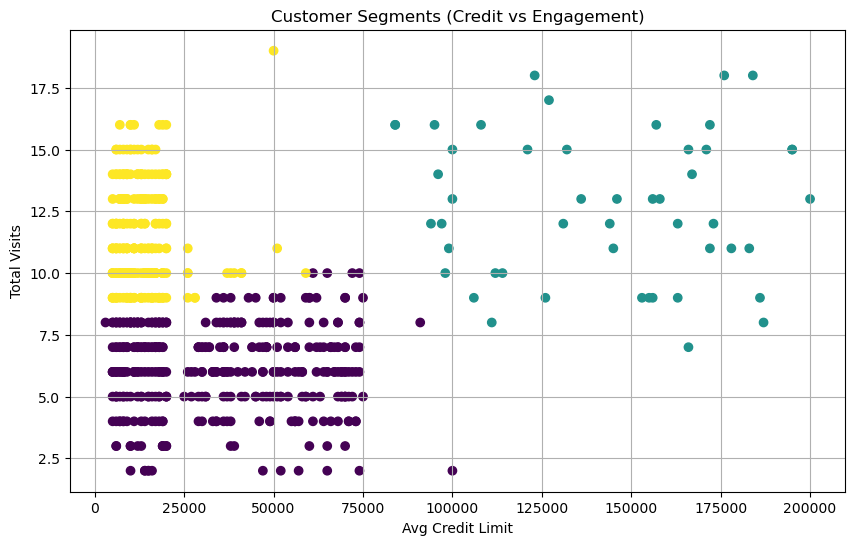

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load data
df = pd.read_csv("Credit Card Customer Data.csv")

# Feature
df['TOTAL_VISITS'] = (
    df['Total_visits_bank'] +
    df['Total_visits_online'] +
    df['Total_calls_made']
)

# Prepare data
X = df[['Avg_Credit_Limit', 'TOTAL_VISITS']]

# Scale
X_scaled = StandardScaler().fit_transform(X)

# Cluster
df['Cluster'] = KMeans(n_clusters=3, random_state=42).fit_predict(X_scaled)

# Scatter Plot
plt.figure(figsize=(10,6))

plt.scatter(
    df['Avg_Credit_Limit'],
    df['TOTAL_VISITS'],
    c=df['Cluster']
)

plt.xlabel("Avg Credit Limit")
plt.ylabel("Total Visits")
plt.title("Customer Segments (Credit vs Engagement)")
plt.grid()

plt.show()

# SAVE FILES

In [55]:
# SAVE FILES

joblib.dump(best_model, "final_model.pkl")
joblib.dump(scaler_cluster, "scaler_cluster.pkl")
joblib.dump(scaler_ml, "scaler_ml.pkl")

df.to_csv("final_output.csv", index=False)

print("\n FULL PIPELINE COMPLETED SUCCESSFULLY")


 FULL PIPELINE COMPLETED SUCCESSFULLY
